In [1]:
import numpy as np
import pandas as pd

import scipy 
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_auc_score

ModuleNotFoundError: No module named 'numpy'

# $$Linear Regression$$ 
## $$ The Three Main Types $$
### **Logistic regression is a classification algorithm used to predict categorical outcomes. Depending on how many categories you have and whether they have a specific order, you will use one of these three variations:**

## $1. Binary Logistic Regression$

- This is the most common type of logistic regression. It is used when the dependent variable (response) has exactly two mutually exclusive outcomes.
    - The Response: Strictly 2 possible outcomes (often coded as 0 or 1).
    - Logical Order: Not applicable (it's simply one or the other).
    - Examples:
        1. Email filtering (Spam vs. Not Spam)
        2. Student exam result (Pass vs. Fail)
        3. Bank loan approval (Approved vs. Rejected)
        4. Event Occurs :
            - Odd's ratio = p/(1-p)
## $2. Nominal Logistic Regression (Multinomial)$

- This is used when the dependent variable has three or more possible outcomes, but there is absolutely no hierarchical order or ranking to them.
    - The Response: 3 or more possible categories.
    - Logical Order: None. All categories are mathematically equal in rank.
    - Examples:
      1. Predicting preferred car color (Red, Blue, Silver, Black)
      2. Categorizing an animal in an image (Cat, Dog, Bird)
      3. Predicting a student's chosen major (Engineering, Arts, Business)
## $3. Ordinal Logistic Regression$
- This is used when the dependent variable has three or more possible outcomes, and those outcomes follow a strict, logical, or ranked order.
    - The Response: 3 or more possible categories.
    - Logical Order: Yes. The levels represent an ascending or descending progression.
    - Examples:
      1. Customer satisfaction surveys (Poor, Fair, Good, Excellent)
      2. Severity of a medical condition (Mild, Moderate, Severe)
      3. Education level (High School, Bachelor's, Master's, PhD)

Encoding Technique


In [124]:
df = pd.read_excel("StudentData.xlsx") 

In [125]:
x_train, x_test, y_train, y_test = train_test_split(df.drop('Marks', axis=1),df.Marks, test_size=0.2, random_state=20)

# Add constant term
x_train = sm.add_constant(x_train, prepend=False)
x_test = sm.add_constant(x_test, prepend=False)

# Prepare the model
mod1 = sm.OLS(y_train,x_train).fit()

print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Marks   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.681
Method:                 Least Squares   F-statistic:                     16.32
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           4.35e-15
Time:                        10:22:50   Log-Likelihood:                -265.81
No. Observations:                  80   AIC:                             555.6
Df Residuals:                      68   BIC:                             584.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Unnamed: 0       -0.0256      0.031     -0.832

In [126]:
df

,Unnamed: 0,StudyHours,PracticeTests,RevisionHours,CoachingHours,Attendance,MobileUsage,NetflixHours,GamingHours,SocialMedia,SportsHours,Marks
0,0,7.0,2.9,7.1,2.6,77.0,6.9,5.5,2.2,7.9,2.4,184.7
1,1,5.7,4.4,5.9,4.2,82.0,8.8,2.2,4.6,5.0,1.6,185.5
2,2,7.3,4.5,7.6,4.7,85.0,2.2,5.7,1.9,6.2,2.0,189.9
3,3,9.0,3.8,9.4,4.0,85.2,6.1,6.7,0.9,5.1,3.3,190.5
4,4,5.5,4.8,5.1,4.8,82.7,3.7,4.8,0.7,5.1,2.2,185.0
...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,3.1,5.6,2.9,5.4,87.7,4.0,3.4,4.6,7.3,1.7,174.7
96,96,6.6,3.7,6.9,3.2,79.8,4.5,4.7,2.9,5.7,3.8,178.1
97,97,6.5,5.2,6.6,5.6,84.0,3.0,1.5,4.0,6.3,2.6,171.6
98,98,6.0,5.1,6.3,5.1,80.6,4.1,5.8,3.0,8.4,1.4,188.4


In [174]:
# Step 1:- 
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name = 'diabetes')

In [175]:
df =df[['Glucose','BloodPressure','Age','DietType','Outcome']]

In [176]:
# Step 2 :- 
 
x = df.drop('Outcome', axis=1)
y = df.Outcome

In [177]:
x

,Glucose,BloodPressure,Age,DietType
0,148,72,50,1
1,85,66,31,2
2,183,64,32,1
3,89,66,21,1
4,137,40,33,1
...,...,...,...,...
763,101,76,63,2
764,122,70,27,1
765,121,72,30,3
766,126,60,47,1


In [178]:
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [179]:
# Step 3 :- 
diet_dummy = pd.get_dummies(x.DietType, drop_first=True, prefix='Diet').astype(int)
x = x.drop('DietType', axis=1)
x = pd.concat([x, diet_dummy], axis=1)

In [180]:
x

,Glucose,BloodPressure,Age,Diet_2,Diet_3
0,148,72,50,0,0
1,85,66,31,1,0
2,183,64,32,0,0
3,89,66,21,0,0
4,137,40,33,0,0
...,...,...,...,...,...
763,101,76,63,1,0
764,122,70,27,0,0
765,121,72,30,0,1
766,126,60,47,0,0


In [181]:
# Step 4 :- 

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=20)

x_train = sm.add_constant(x_train, prepend=False)
mod3 = sm.Logit(y_train, x_train).fit()
print(mod3.summary())

Optimization terminated successfully.
         Current function value: 0.333614
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  614
Model:                          Logit   Df Residuals:                      608
Method:                           MLE   Df Model:                            5
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                  0.4848
Time:                        10:31:21   Log-Likelihood:                -204.84
converged:                       True   LL-Null:                       -397.59
Covariance Type:            nonrobust   LLR p-value:                 3.933e-81
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Glucose           0.0368      0.005      7.867      0.000       0.028       0.046
BloodPressure     0.

In [182]:
# Testing the model - Fixed version
# Option 1: Provide data for all 12 columns that match x_train
mydata = pd.DataFrame([[100,75,50,1,0,1,0,0,0,0,0,0],[100,75,51,1,0,1,0,0,0,0,0,0]], columns = x_train.columns)

# Option 2: Use only the first 6 columns from x_train
# mydata = pd.DataFrame([[100,75,50,1,0,1],[100,75,51,1,0,1]], columns = x_train.columns[:6])

# Option 3: Create DataFrame without specifying columns and add them later
# mydata = pd.DataFrame([[100,75,50,1,0,1],[100,75,51,1,0,1]])

ValueError: 6 columns passed, passed data had 12 columns

In [136]:

LOR_51 = np.log(0.069934/(1-0.069934))


In [137]:

LOR_50 = np.log(0.067899/(1-0.067899))


The coefficent of the 0317 indicates, that when they increase by 1 unit the change()

In [138]:
mydata

,Unnamed: 0,StudyHours,PracticeTests,RevisionHours,CoachingHours,Attendance
0,100,75,50,1,0,1
1,100,75,51,1,0,1


In [139]:
LOR_51 - LOR_50

np.float64(0.03171625976306691)

In [140]:
x_train.head()

,Glucose,BloodPressure,Age,Diet_2,Diet_3,const
446,100,72,28,1,0,1.0
260,191,68,34,1,0,1.0
570,78,70,39,1,0,1.0
590,111,84,45,0,0,1.0
30,109,75,60,1,0,1.0


In [141]:
(np.log(0.131953/(1-0.131953)) - np.log(0.067899/(1-0.067899)))/20

np.float64(0.036780990445645666)

In [142]:
# Testing the model - Fixed version
# Option 1: Provide data for all 12 columns that match x_train
# mydata = pd.DataFrame([[100,75,50,1,0,1,0,0,0,0,0,0],[100,75,51,1,0,1,0,0,0,0,0,0]], columns = x_train.columns)

# Option 2: Use only the first 6 columns from x_train
mydata = pd.DataFrame([[100,75,50,1,0,1],[100,75,51,1,0,1]], columns = x_train.columns[:6])

# Option 3: Create DataFrame without specifying columns and add them later
# mydata = pd.DataFrame([[100,75,50,1,0,1],[100,75,51,1,0,1]])

In [143]:
mydata

,Glucose,BloodPressure,Age,Diet_2,Diet_3,const
0,100,75,50,1,0,1
1,100,75,51,1,0,1


In [144]:
mypreds=mod3.predict(mydata)

In [145]:
mypreds

0    0.067899
1    0.069934
dtype: float64

# $One Hot Encoding$

In [146]:
df = pd.DataFrame({
    'Education':[
        'Graduate',
        'PG',
        'High School',
        'Graduate',
        'PG'
    ]
})


In [147]:

education_map = {
    'High School':1,
    'Graduate':2,
    'PG':3
}

df['Education_Encoded'] = (
    df['Education']
    .map(education_map)
)


In [148]:
print(df)

     Education  Education_Encoded
0     Graduate                  2
1           PG                  3
2  High School                  1
3     Graduate                  2
4           PG                  3


- Frequency Encoding

In [149]:
# Frequency encoding
df = pd.DataFrame({
    'City':[
        'Mumbai',
        'Mumbai',
        'Mumbai',
        'Delhi',
        'Delhi',
        'Pune'
    ]
})

freq = df.City.value_counts()

df['City_Frequency'] = (df.City.map(freq))

In [150]:
df

,City,City_Frequency
0,Mumbai,3
1,Mumbai,3
2,Mumbai,3
3,Delhi,2
4,Delhi,2
5,Pune,1


In [151]:
df = pd.DataFrame({
    'City': [
        'Mumbai',
        'Pune',
        'Delhi',
        'Chennai',
        'Kolkata'
    ]
})


!pip install category_encoders

from category_encoders import BinaryEncoder
encoder = BinaryEncoder(cols=['City'])
df_encoded = encoder.fit_transform(df)
print(df_encoded)

df_encoded = encoder.transform(df)
result = pd.concat([df, df_encoded], axis=1)
print(result)

   City_0  City_1  City_2
0       0       0       1
1       0       1       0
2       0       1       1
3       1       0       0
4       1       0       1
      City  City_0  City_1  City_2
0   Mumbai       0       0       1
1     Pune       0       1       0
2    Delhi       0       1       1
3  Chennai       1       0       0
4  Kolkata       1       0       1


## $$ 5. PML  Model  Training  (08/06/2026) $$ 

In [152]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name = 'diabetes')

df =df[['Glucose','BloodPressure','Age','DietType','Outcome']]

x = df.drop('Outcome', axis=1)
y = df.Outcome

diet_dummy = pd.get_dummies(x.DietType, drop_first=True, prefix='Diet').astype(int)
x = x.drop('DietType', axis=1)
x = pd.concat([x, diet_dummy], axis=1)

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=20)

x_train = sm.add_constant(x_train, prepend=False)
mod3 = sm.Logit(y_train, x_train).fit()
print(mod3.summary())

Optimization terminated successfully.
         Current function value: 0.333614
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  614
Model:                          Logit   Df Residuals:                      608
Method:                           MLE   Df Model:                            5
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                  0.4848
Time:                        10:22:57   Log-Likelihood:                -204.84
converged:                       True   LL-Null:                       -397.59
Covariance Type:            nonrobust   LLR p-value:                 3.933e-81
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Glucose           0.0368      0.005      7.867      0.000       0.028       0.046
BloodPressure     0.

In [153]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
print(classification_report(y_train,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89       399
           1       0.82      0.76      0.79       215

    accuracy                           0.86       614
   macro avg       0.85      0.84      0.84       614
weighted avg       0.86      0.86      0.86       614



In [154]:
y_probs = mod3.predict(x_train)
y_pred = []
for ctr in y_probs:
    if ctr >= 0.5:
        y_pred.append(1)
    else:
        y_pred.append(0)
print(confusion_matrix(y_train,y_pred))        

[[362  37]
 [ 51 164]]


In [155]:
(362+164)/(362+164+51+37)

0.8566775244299675

In [156]:
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89       399
           1       0.82      0.76      0.79       215

    accuracy                           0.86       614
   macro avg       0.85      0.84      0.84       614
weighted avg       0.86      0.86      0.86       614



In [157]:
x_train.shape

(614, 6)

In [172]:
(0.88*399 + 0.82*215)/614

0.8589902280130293

In [159]:
(2*0.88*0.91)/(0.88+0.91)


0.8947486033519554

In [160]:
(2*0.82*0.76)/(0.82+0.76)

0.7888607594936708

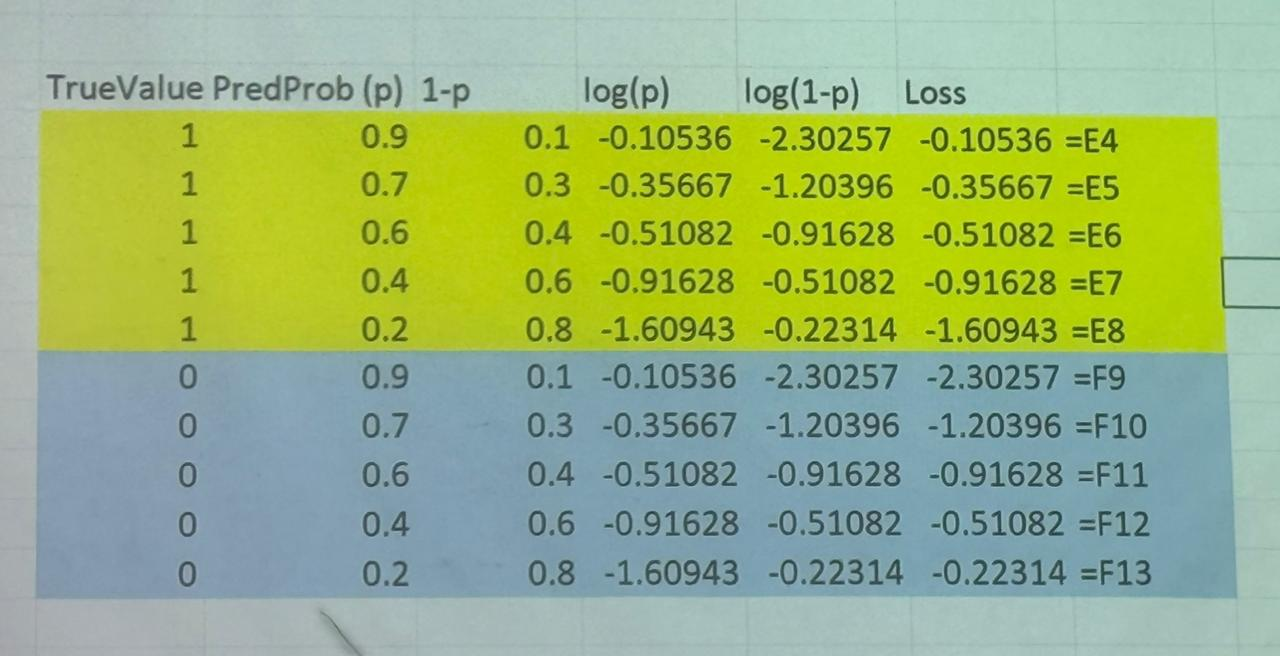

In [170]:
from IPython.display import Image, display

display(Image(filename="/Users/gajendra06/Documents/Documents/CDAC_BDA/8_PML/log loss.jpeg", width=600))

### This table is a manual calculation of the core components of Binary Cross-Entropy, often referred to as Log Loss. In data science and machine learning, this is the standard mathematical way to evaluate how well a classification model is performing. 

**1. The Core Objective**
- When you predict probabilities for a binary outcome (where the TrueValue is strictly 1 or 0), you want to heavily penalize the model if it is extremely confident about the wrong answer.
- The standard statistical formula for a single observation's Log Loss is:
- L=−[ylog(p)+(1−y)log(1−p)]
    - Where:
        - y is the TrueValue (actual label).
        - p is the PredProb (predicted probability of class 1).

**2. Reading the Yellow Section (y=1)**
- When the actual outcome is 1, the right side of the formula (1−y) becomes zero. Therefore, the model's penalty is judged entirely by log(p).
- Look at the first row: the model predicted p=0.9. Because this is very close to the true value of 1, log(0.9) results in a very small negative number (−0.10536).
- Look at the fifth row: the model predicted p=0.2. The model was very wrong, so log(0.2) results in a much larger negative penalty (−1.60943).

**3. Reading the Blue Section (y=0)**
- When the actual outcome is 0, the left side of the formula (y) becomes zero. The model is now judged entirely by the predicted probability of the other class, which is 1−p.
    - **Look at the last row:** the model predicted p=0.2, meaning it correctly guessed a low probability for class 1. Therefore, 1−p=0.8. The calculation relies on log(0.8), resulting in a small penalty (−0.22314).
    - **Look at the sixth row:** the model predicted p=0.9 when the truth was 0. Because it was confidently wrong, 1−p=0.1. The calculation uses log(0.1), generating a massive penalty (−2.30257).
- A Minor Nuance in the Table
Typically, loss functions are designed to be positive numbers that we aim to minimize. The table in your image calculates the raw log-probabilities (which are negative). In practice, algorithms multiply this result by −1 to create a positive Log Loss score.
- Interactive Log Loss Explorer
To help visualize how these penalties shift depending on the true class, I've created an interactive calculator below. I have initialized it with the first row of your table (y=1,p=0.9). Try adjusting the predicted probability to see how the mathematical penalty curves dynamically update.

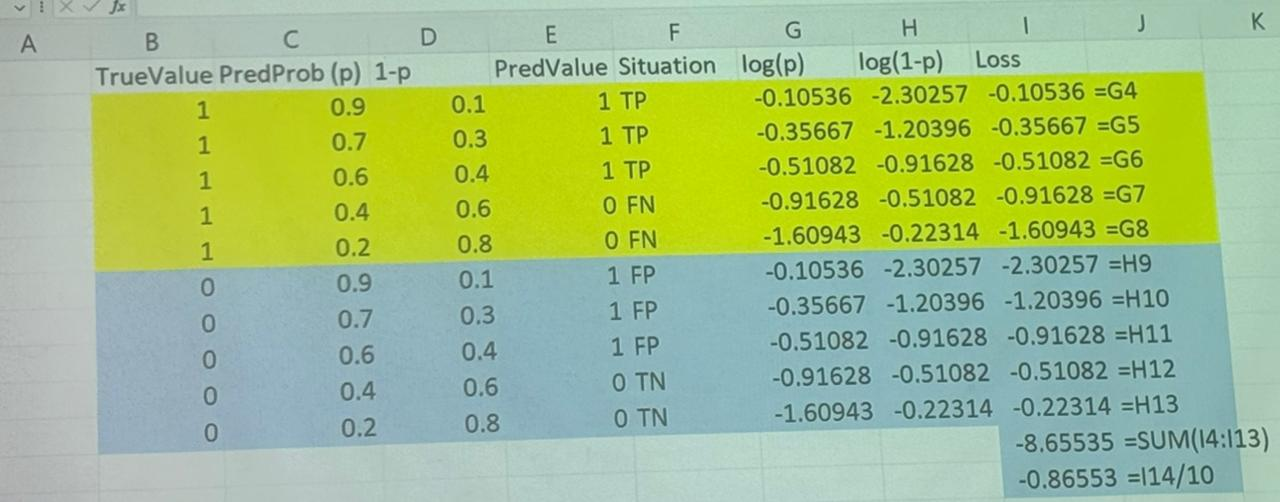

In [169]:
display(Image(filename="/Users/gajendra06/Documents/Documents/CDAC_BDA/8_PML/log_loss1.jpeg", width=600))
              

In [163]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name = 'diabetes')

df =df[['Glucose','BloodPressure','Age','DietType','Outcome']]

x = df.drop('Outcome', axis=1)
y = df.Outcome

diet_dummy = pd.get_dummies(x.DietType, drop_first=True, prefix='Diet').astype(int)
x = x.drop('DietType', axis=1)
x = pd.concat([x, diet_dummy], axis=1)

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=20)

x_train = sm.add_constant(x_train, prepend=False)
mod3 = sm.Logit(y_train, x_train).fit()
print(mod3.summary())

y_probs = mod3.predict(x_train)
y_pred = []
for ctr in y_probs:
    if ctr>=0.5:
        y_pred.append(1)
    else:
        y_pred.append(0)
        
print(confusion_matrix(y_train,y_pred))

from sklearn.metrics import classification_report
print(classification_report(y_train,y_pred))

log_loss = 0

for ctr in range(len(y_train)):
    if y_train.iloc[ctr]==1:
        log_loss= log_loss + np.log((y_probs.iloc[ctr]))
    else:
        log_loss= log_loss + np.log((1-y_probs.iloc[ctr]))

Optimization terminated successfully.
         Current function value: 0.333614
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  614
Model:                          Logit   Df Residuals:                      608
Method:                           MLE   Df Model:                            5
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                  0.4848
Time:                        10:23:00   Log-Likelihood:                -204.84
converged:                       True   LL-Null:                       -397.59
Covariance Type:            nonrobust   LLR p-value:                 3.933e-81
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Glucose           0.0368      0.005      7.867      0.000       0.028       0.046
BloodPressure     0.

### **Example 1: Glucose (A Significant Continuous Predictor)**
Step 1: Null hypothesis m=0 (The coefficient of Glucose is 0; it has no effect on the Outcome).
Step 2: P-value = 0.000
Step 3: Decision based on p-value: Reject the null hypothesis (since 0.000 < 0.05).
Step 4: Conclusion: Glucose significantly influences the Outcome.
Step 5: What is the effect? When Glucose is increased by one unit, the log-odds of the Outcome will increase by 0.0368, keeping other factors constant. (In plain English: Higher glucose increases the probability of the Outcome happening).

### **Example 2: Blood Pressure (An Insignificant Predictor)**
Step 1: Null hypothesis m=0 (The coefficient of BloodPressure is 0; it has no effect on the Outcome).
Step 2: P-value = 0.395
Step 3: Decision based on p-value: Fail to reject the null hypothesis (since 0.395 > 0.05).
Step 4: Conclusion: Blood Pressure does not significantly influence the Outcome.
Step 5: What is the effect? Because the p-value is greater than 0.05, the coefficient of 0.0058 is not statistically reliable. We conclude that Blood Pressure has no measurable effect on the Outcome in this model.
### **Example 3: Diet_2 (A Categorical Predictor)**
Note: In categorical variables, the coefficient is compared to the dropped "baseline" category (Diet_1).
Step 1: Null hypothesis m=0 (The coefficient of Diet_2 is 0; it has no effect compared to the baseline Diet_1).
Step 2: P-value = 0.000
Step 3: Decision based on p-value: Reject the null hypothesis.
Step 4: Conclusion: Being on Diet 2 significantly influences the Outcome compared to Diet 1.
Step 5: What is the effect? If a patient is on Diet 2, the log-odds of the Outcome will decrease by 3.9276 compared to someone on Diet 1, keeping other factors (Age, Glucose, BP) constant. (In plain English: Diet 2 massively reduces the probability of the Outcome happening compared to Diet 1).

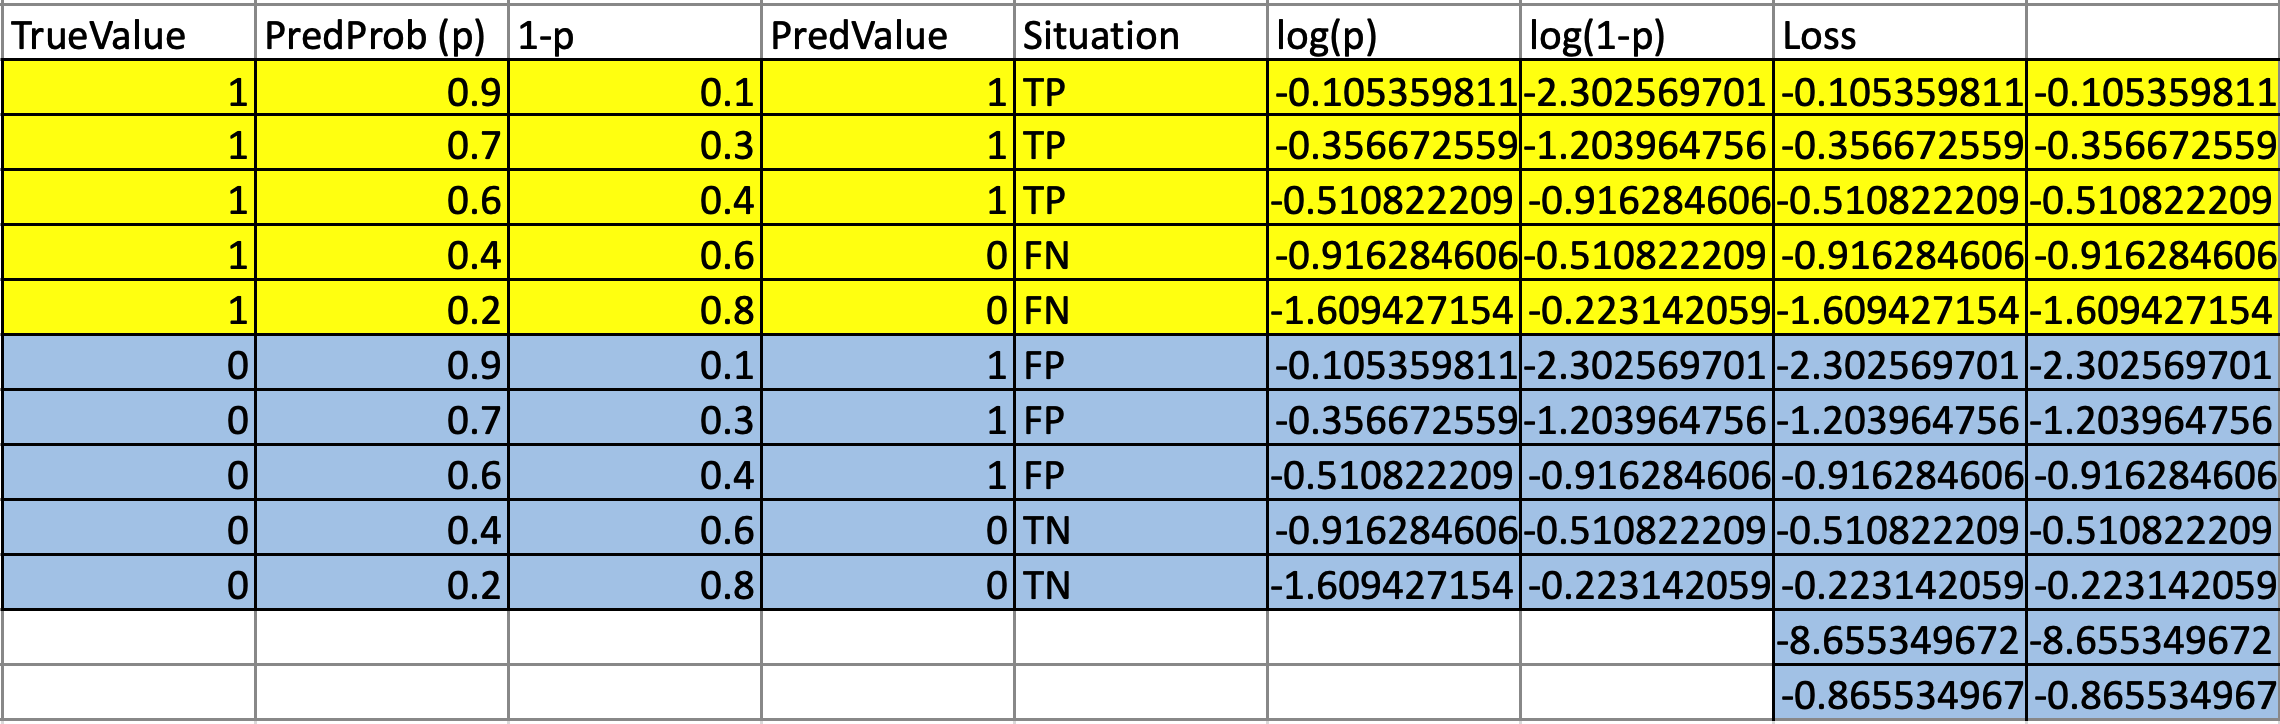

In [168]:
display(Image(filename = "/Users/gajendra06/Documents/Documents/CDAC_BDA/8_PML/Log_loss2.png", width=700))

## $$ 6. PML  Model  Training  (09/06/2026) $$ 

### **Performance of Regression Model**

## **Threshold**

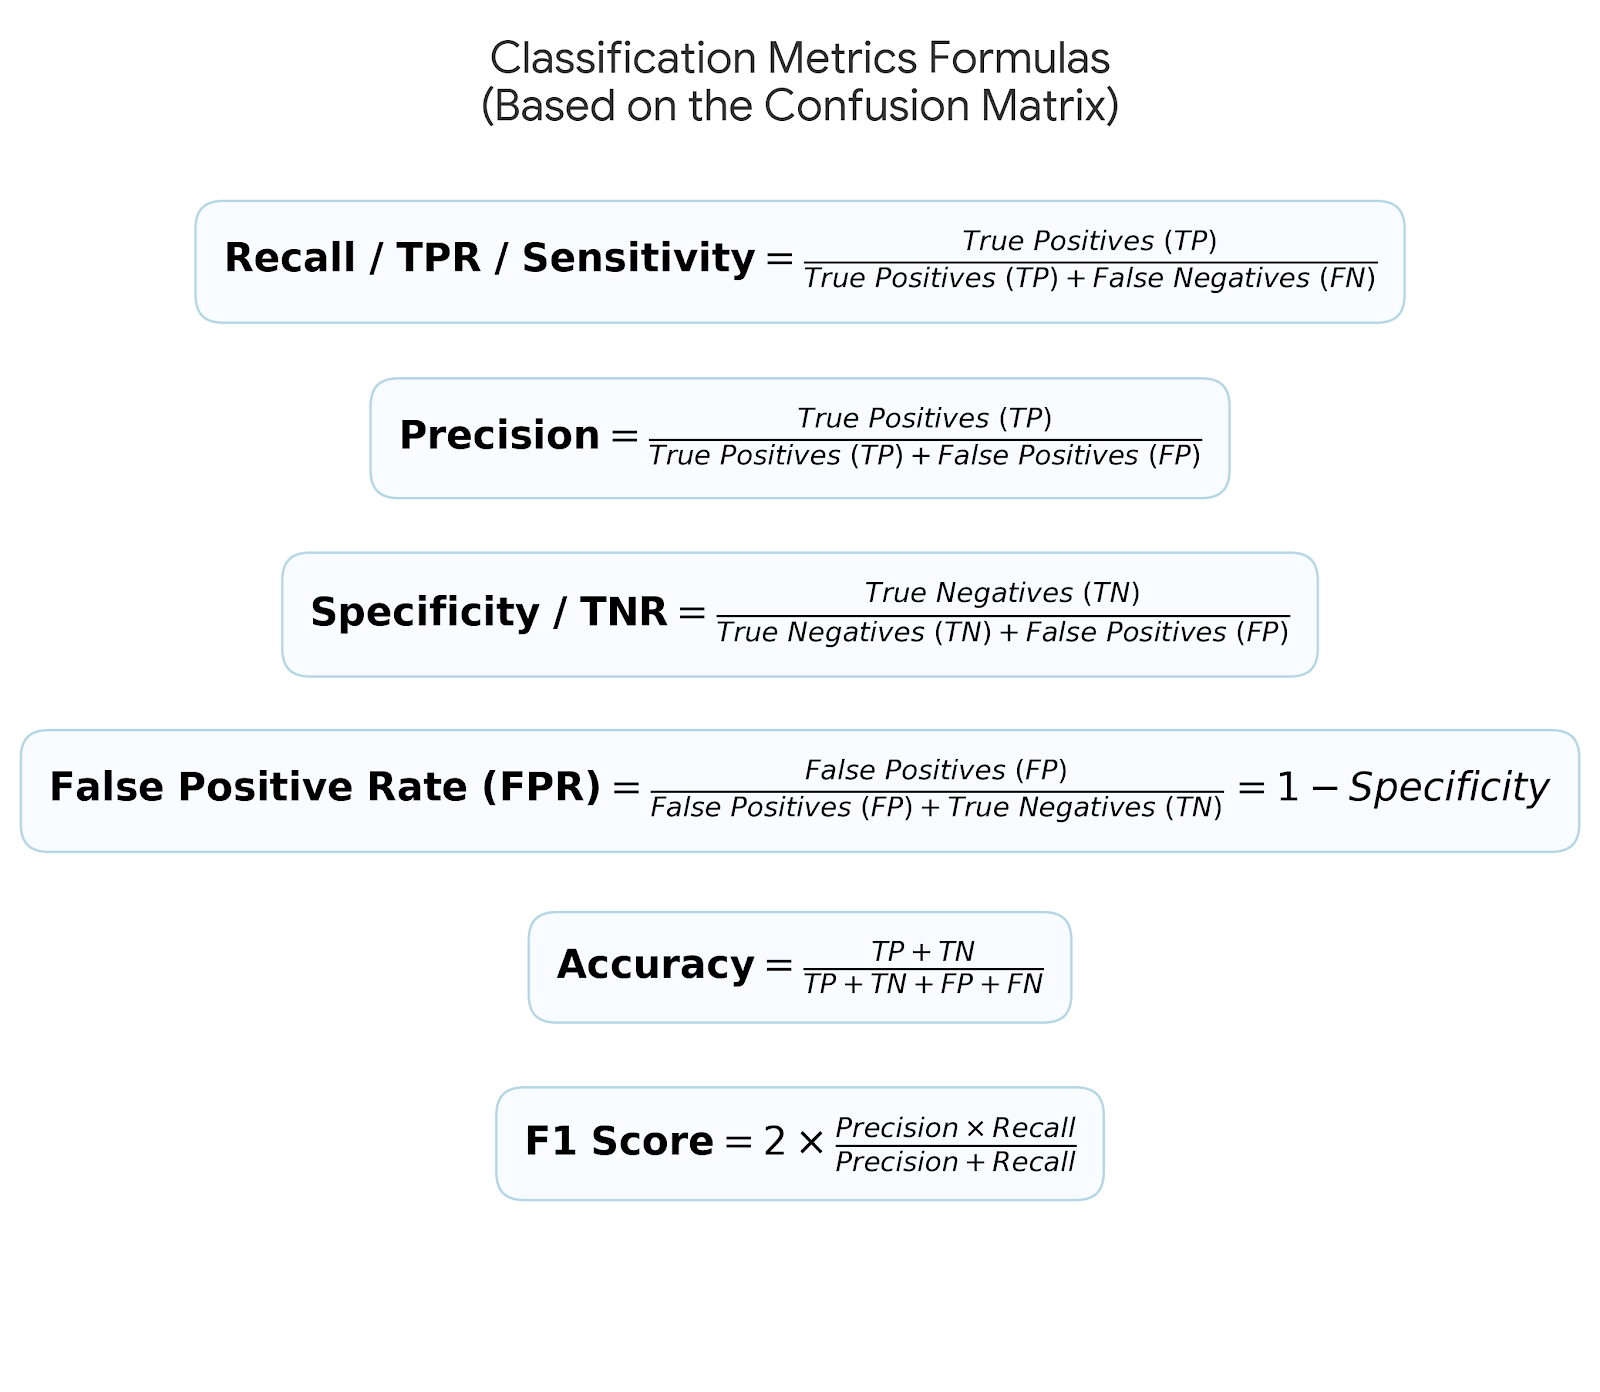

In [184]:
display(Image(filename="/Users/gajendra06/Documents/Documents/CDAC_BDA/8_PML/formulas.png", width=500))

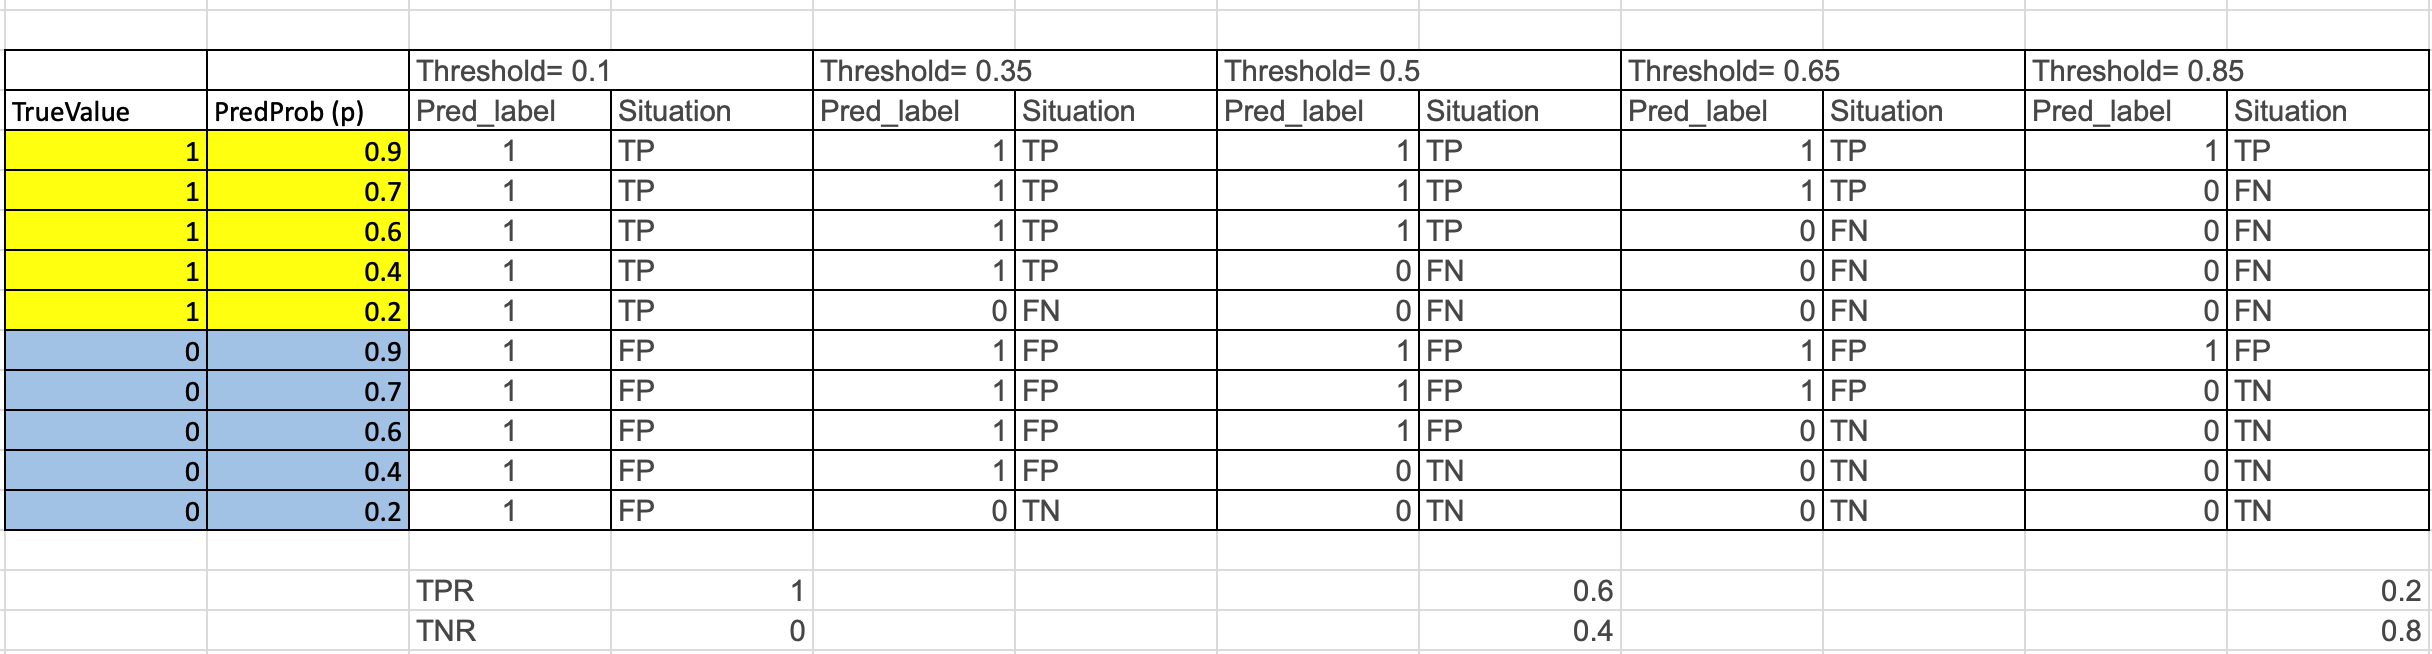

In [165]:
display(Image(filename="/Users/gajendra06/Documents/Documents/CDAC_BDA/8_PML/Threshold.png", width=700))


## Classification Thresholds & Trade-offs

In logistic regression, the model outputs a **probability** (e.g., 0.72 or 72%). The **Threshold** (or cut-off value) is the exact boundary we set to force the model into making a binary decision (0 or 1).

Changing the threshold shifts the types of mistakes the model makes, representing a trade-off between **Precision** and **Recall**.

### 1. The Default Threshold (0.50 or 50%)
By default, algorithms use a balanced 50% cut-off.
* **Rule:** If Probability ≥ 50%, predict **1** (Positive). If < 50%, predict **0** (Negative).
* **The Problem:** This assumes False Positives and False Negatives have the same business cost, which is rarely true.

### 2. Lowering the Threshold (e.g., 0.20 or 20%)
*Makes the model "Aggressive" or "Trigger-Happy."*
* **Rule:** If the model is even 20% sure, it predicts **1**.
* **Trade-off:**
  * **Recall goes UP:** You catch almost all actual positive cases.
  * **Precision goes DOWN:** You generate many False Alarms (False Positives).
* **Real-World Use Case (Cancer Screening):** You would rather have 100 false alarms (causing panic/more tests) than miss a single actual cancer patient (a fatal False Negative).

### 3. Raising the Threshold (e.g., 0.80 or 80%)
*Makes the model "Strict" or "Conservative."*
* **Rule:** The model must be 80% confident before predicting **1**.
* **Trade-off:**
  * **Precision goes UP:** When it rings the alarm, it is almost certainly correct.
  * **Recall goes DOWN:** You miss actual positive cases (False Negatives) because the model was too hesitant.
* **Real-World Use Case (Spam Filters):** You would rather let 10 spam emails into your inbox (False Negatives) than accidentally send an important email from your boss to the Spam folder (a False Positive).

---
**The Bottom Line:** There is no mathematically "perfect" threshold. The optimal cut-off is always determined by the **business cost of a mistake**.

In [173]:
y_true= [1,0,0,1,1,0]
y_pred = [0.93,0.83, 0.31, 0.73, 0.25, 0.37]

roc_auc_score(y_true, y_pred)

0.5555555555555556

In [187]:
from statsmodels.discrete.discrete_model import MNLogit

df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name='nominal')
df = df.drop('write', axis=1)

x = df.drop('prog', axis=1)
y = df.prog

ses_dummy = pd.get_dummies(x.ses, drop_first=True, prefix='SES').astype(int)
x.drop('ses', axis=1, inplace=True)
x = pd.concat([x,ses_dummy], axis=1)

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=20)

x_train = sm.add_constant(x_train, prepend=False)
mod1 = sm.MNLogit(y_train, x_train).fit()
print(mod1.summary())

Optimization terminated successfully.
         Current function value: 0.653667
         Iterations 8
                          MNLogit Regression Results                          
Dep. Variable:                   prog   No. Observations:                  160
Model:                        MNLogit   Df Residuals:                      152
Method:                           MLE   Df Model:                            6
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                  0.3687
Time:                        12:57:45   Log-Likelihood:                -104.59
converged:                       True   LL-Null:                       -165.68
Covariance Type:            nonrobust   LLR p-value:                 5.678e-24
    prog=2       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
math           0.0112      0.036      0.312      0.755      -0.059       0.082
SES_2          3.2174      0.

## MNLogit Coefficients Analysis: Program 2 vs. Baseline (Program 1)

When comparing Program 2 directly to the baseline Program 1, **none of the actual predictor variables have a negative coefficient.** They all actively *increase* the probability of a student choosing Program 2. 

Here is the mathematical breakdown of where the probability increases, and the two exceptions where the math shifts back toward Program 1:

### 1. The Predictors (Increasing Probability of Program 2)
Because these coefficients are positive, they all push the probability away from Program 1 and toward Program 2:
* **Math (`0.0112`):** Positive. As math scores go up, the probability of choosing Program 2 increases.
* **SES_2 (`3.2174`):** Positive. Being in SES Level 2 increases the probability of choosing Program 2 compared to SES Level 1.
* **SES_3 (`2.4719`):** Positive. Being in SES Level 3 increases the probability of choosing Program 2 compared to SES Level 1.

### 2. The Exceptions (Decreasing / Shifting Probability)
If you are looking for where the model's math decreases or shifts probability *back* toward Program 1, it happens in these two places:
* **The Constant / Intercept (`-1.0727`):** The constant is negative. This means the *default baseline* leans heavily toward Program 1. If a student had a Math score of 0 and was in SES Level 1, this negative constant means they have a much higher base probability of being in Program 1 than Program 2.
* **The Drop from SES_2 to SES_3:** The coefficient for `SES_2` is **3.2174**, but the coefficient drops down to **2.4719** for `SES_3`. This means that while both groups prefer Program 2 over Program 1, the middle class (SES 2) has the absolute highest probability of choosing Program 2. When a student moves up from SES 2 to SES 3, their probability of choosing Program 2 actually *decreases* relative to SES 2.

In [189]:
mydata = pd.DataFrame([[60,0,0,1],[60,1,0,1]], columns=x_train.columns)

In [190]:
mydata


,math,SES_2,SES_3,const
0,60,0,0,1
1,60,1,0,1


In [191]:
mod1.predict(mydata)

,0,1,2
0,0.56349,0.377273,0.059237
1,0.02383,0.398299,0.577871


## **Ordinal Logistic Regression**
- - -
- The Ordinal Logistic regression is used when your response is multi categorical with the logical order
  - Ex :- Rating and Ranking

In [192]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name='ordinal')

reg_dummy = pd.get_dummies(df.Region, drop_first=True, prefix='Region').astype(int)
df.drop('Region', axis=1, inplace=True)
df = pd.concat([df,reg_dummy], axis=1)
df.Survival = pd.Categorical(df.Survival, categories=[1,2,3],ordered=True)

x_train, x_test, y_train, y_test = train_test_split(df.drop('Survival',axis=1),df.Survival,test_size=0.2, random_state=20)

mod1=OrderedModel(y_train,x_train,distr='logit').fit(method='bfgs')
print(mod1.summary())

Optimization terminated successfully.
         Current function value: 0.847944
         Iterations: 19
         Function evaluations: 22
         Gradient evaluations: 22
                             OrderedModel Results                             
Dep. Variable:               Survival   Log-Likelihood:                -49.181
Model:                   OrderedModel   AIC:                             106.4
Method:            Maximum Likelihood   BIC:                             114.6
Date:                Tue, 09 Jun 2026                                         
Time:                        16:40:56                                         
No. Observations:                  58                                         
Df Residuals:                      54                                         
Df Model:                           2                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

In [193]:
import statsmodels.formula.api as smf
from statsmodels.discrete.discrete_model import Poisson as psn
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name='poisson')
prog_dummy = pd.get_dummies(df.prog, drop_first=True,prefix='prog').astype(int)
df = df.drop('prog', axis=1)
df = pd.concat([df,prog_dummy], axis=1)
x_train, x_test, y_train, y_test = train_test_split(df.drop('num_awards', axis=1), df['num_awards'], test_size=0.2,random_state=20)
x_train1 = sm.add_constant(x_train, prepend=False)

df_train = pd.concat([x_train1,y_train], axis=1)

mod2 = psn.from_formula("num_awards ~ math+prog_2+prog_3", data=df_train).fit()

Optimization terminated successfully.
         Current function value: 0.871654
         Iterations 6


In [194]:
print(mod2.summary())

                          Poisson Regression Results                          
Dep. Variable:             num_awards   No. Observations:                  160
Model:                        Poisson   Df Residuals:                      156
Method:                           MLE   Df Model:                            3
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                  0.1865
Time:                        17:09:14   Log-Likelihood:                -139.46
converged:                       True   LL-Null:                       -171.44
Covariance Type:            nonrobust   LLR p-value:                 8.447e-14
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.0741      0.780     -6.503      0.000      -6.603      -3.545
math           0.0661      0.013      5.154      0.000       0.041       0.091
prog_2         1.1048      0.407      2.711      0.0

In [196]:
# Prog 2 
# with respect to prog_1 we are moving to prog_2 it doesn't influence job offer 
# null hypothesis is 0
#m



In [198]:
from statsmodels.discrete.discrete_model import NegativeBinomial as ngb
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name='neg_bin')
prog_dummy = pd.get_dummies(df['prog'], drop_first=True,prefix='prog').astype(int)
df = df.drop('prog', axis=1)
df = pd.concat([df,prog_dummy], axis=1)
x_train, x_test, y_train, y_test = train_test_split(df.drop('daysabs',axis=1), df['daysabs'], test_size=0.2,random_state=20)
x_train1 = sm.add_constant(x_train)
df_train = pd.concat([x_train1,y_train], axis=1)
model3 = ngb.from_formula("daysabs ~ math+prog_General+prog_Vocational", data=df_train).fit()
model3.summary()

Optimization terminated successfully.
         Current function value: 2.819371
         Iterations: 19
         Function evaluations: 26
         Gradient evaluations: 26


<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:                daysabs   No. Observations:                  251
Model:               NegativeBinomial   Df Residuals:                      247
Method:                           MLE   Df Model:                            3
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                 0.03229
Time:                        21:33:39   Log-Likelihood:                -707.66
converged:                       True   LL-Null:                       -731.28
Covariance Type:            nonrobust   LLR p-value:                 3.104e-10
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.2587      0.144     15.644      0.000       1.976       2.542
math               -0.0070      0.003     -2.506      0.012      -0.012      -0.002
prog_General        0.3942      0.198      1.989      0.047       0.006       0.783
prog_Vocational    -0.7389      0.160     -4.616      0.000      -1.053      -0.425
alpha               0.9326      0.106      8.811      0.000       0.725       1.140
===================================================================================
"""

## $$ 7. PML  Model  Training  (10/06/2026) $$ 

In [200]:
df = pd.read_csv("/Users/gajendra06/Documents/Documents/CDAC_BDA/8_PML/Titanic.csv")

In [201]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [203]:
df['num']= df.SibSp+df.Parch

In [204]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,num
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


In [205]:
df.info()df = df.drop(['PassengerId','Name','Ticket','Cabin'], axis=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  num          891 non-null    int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 90.6+ KB


In [206]:
df = df.drop(['PassengerId','Name','Ticket','Cabin'], axis=1)

In [207]:
df.Age = df.Age.fillna(df.Age.median())

In [208]:
df.Embarked.mode()

0    S
Name: Embarked, dtype: object

In [209]:
df.Embarked = df.Embarked.fillna('S')

In [210]:
df = df.drop(['SibSp','Parch'], axis=1)

In [211]:
dum_Pclass = pd.get_dummies(df.Pclass,drop_first=True,prefix='Pclass').astype(int)
dum_sex = pd.get_dummies(df.Sex,drop_first=True,prefix='Gender').astype(int) 
dum_embarked = pd.get_dummies(df.Embarked,drop_first=True,prefix='Embark').astype(int) 


In [212]:
# df = pd.read_csv('titanic.csv')

# df = df.drop(['PassengerId','Name','Ticket','Cabin'], axis=1)
#df.info()
#df.Age = df.Age.fillna(df.Age.median())
#df.Embarked.mode()
# df.Embarked = df.Embarked.fillna('S')

# df['NumPass'] = df.SibSp + df.Parch
# df = df.drop(['SibSp','Parch'], axis=1)

#dum_Pclass = pd.get_dummies(df.Pclass,drop_first=True,prefix='Pclass').astype(int)
#dum_sex = pd.get_dummies(df.Sex,drop_first=True,prefix='Gender').astype(int) 
# dum_embarked = pd.get_dummies(df.Embarked,drop_first=True,prefix='Embark').astype(int) 

df = df.drop(['Pclass','Sex','Embarked'],axis=1)
df = pd.concat([df,dum_Pclass,dum_sex,dum_embarked], axis=1)

In [213]:
df.head()

,Survived,Age,Fare,num,Pclass_2,Pclass_3,Gender_male,Embark_Q,Embark_S
0,0,22.0,7.2500,1,0,1,1,0,1
1,1,38.0,71.2833,1,0,0,0,0,0
2,1,26.0,7.9250,0,0,1,0,0,1
3,1,35.0,53.1000,1,0,0,0,0,1
4,0,35.0,8.0500,0,0,1,1,0,1


In [220]:
x = df.drop('Survived',axis=1)
y = df.Survived


x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=20)

# Importing Decision Tree library
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(max_depth=3)

dtc.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [221]:
dtc.fit(x_train,y_train)
dtc.score(x_train,y_train) # Age accuracy on train set.

0.8258426966292135

In [222]:
dtc.score(x_test,y_test)

0.8156424581005587

In [223]:
y_pred= dtc.predict(x_test)

In [224]:
print(confusion_matrix(y_test,y_pred))

[[107   5]
 [ 28  39]]


### - **A model  parameter  is  a  variable  of  the selected model which can be estimated by fitting the given data to the model.**

In [225]:
# Hyper paramerter 
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()
param = {'max_depth':[2,3,4,5],
         'splitter':['best','random'],
         'criterion':['gini','entropy'],
         'min_samples_leaf':[2,3,4,5,6]}

from sklearn.model_selection import GridSearchCV

mod1 = GridSearchCV(dtc,param_grid=param,cv=5,scoring='accuracy')
mod1.fit(x_train,y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [2, 3, ...], 'splitter': ['best', 'random']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [229]:
df = pd.read_csv('titanic.csv')

df = df.drop(['PassengerId','Name','Ticket','Cabin'], axis=1)
df.info()
df.Age = df.Age.fillna(df.Age.median())
df.Embarked.mode()
df.Embarked = df.Embarked.fillna('S')

df['NumPass'] = df.SibSp + df.Parch
df = df.drop(['SibSp','Parch'], axis=1)

dum_Pclass = pd.get_dummies(df.Pclass,drop_first=True,prefix='Pclass').astype(int)
dum_sex = pd.get_dummies(df.Sex,drop_first=True,prefix='Gender').astype(int) 
dum_embarked = pd.get_dummies(df.Embarked,drop_first=True,prefix='Embark').astype(int) 

df = df.drop(['Pclass','Sex','Embarked'],axis=1)
df = pd.concat([df,dum_Pclass,dum_sex,dum_embarked], axis=1)

x=df.drop('Survived',axis=1)
y=df.Survived

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=20)

from sklearn.tree import DecisionTreeClassifier

# define instance for DecisionTreeClassifier WITHOUT hyperparameters
dtc = DecisionTreeClassifier()
dtc.fit(x_train,y_train)
dtc.score(x_train,y_train)   # %age accuracy on training set
dtc.score(x_test,y_test)
# the big gap between training and test accuracy suggests overfitting

# to remove overfitting, hyper parameter values need to be set
# to get the best values for the the hyperparameters we do the Grid Search CV

param = {'max_depth':[2,3,4,5,6,7,8],
         'splitter':['best','random'],
         'criterion':['gini','entropy'],
         'min_samples_leaf':[2,3,4,5,6]}

from sklearn.model_selection import GridSearchCV

mod1 = GridSearchCV(dtc,param_grid=param,cv=5,scoring='accuracy')
mod1.fit(x_train,y_train)

mod1.best_params_

# the above command gives the most appropriate values for the different hyperparameters

# define the instance dtc WITH hyperparameters
dtc = DecisionTreeClassifier(criterion='gini',
 max_depth=5,
 min_samples_leaf=2,
 splitter='best')

dtc.fit(x_train,y_train)
dtc.score(x_train,y_train)   # %age accuracy on training set
dtc.score(x_test,y_test)

y_pred = dtc.predict(x_test)

print(confusion_matrix(y_test,y_pred))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB
[[106   6]
 [ 27  40]]
